In [2]:
import pandas as pd
import os
import time
import requests

# โหลดไฟล์ต้นฉบับ
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/email2-QC/Email2.csv'
df_ori = pd.read_csv(file_path, encoding='utf-8-sig')

# สร้างคอลัมน์ audio_index ขึ้นมาใหม่ โดยเริ่มที่ 0, 1, 2...
df_ori['audio_index'] = df_ori.index


# สร้างโฟลเดอร์สำหรับเก็บไฟล์เสียง
temp_audio_path = 'temp_audio_email2'
if not os.path.exists(temp_audio_path):
    os.makedirs(temp_audio_path)

print(f"📊 โหลดข้อมูลมาทั้งหมด {len(df_ori)} แถวเรียบร้อย")

📊 โหลดข้อมูลมาทั้งหมด 15013 แถวเรียบร้อย


# Define Functions

In [4]:

def classify_qc(trim_dur, ratio, text):
    """ฟังก์ชันตัดสินสถานะตามเกณฑ์ใหม่ 3.65 และเช็ก NaN"""
    if pd.isna(text) or str(text).strip().lower() == 'nan':
        return "Abnormal: Text Missing"
    if trim_dur < 0.5:
        return "Abnormal: Too Short"
    if ratio > 3.65:
        return "Abnormal: Too Fast"
    if ratio < 0.5:
        return "Abnormal: Too Slow"
    return "Passed"

def download_with_retry(url, dest, retries=2):
    """ฟังก์ชันโหลดไฟล์พร้อมระบบลองใหม่ (Retry)"""
    for i in range(retries + 1):
        try:
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                with open(dest, 'wb') as f:
                    f.write(resp.content)
                return True
        except:
            if i < retries: time.sleep(1) # รอ 1 วินาทีก่อนลองใหม่
    return False

# Calculating Ratio

In [5]:
import numpy as np
from tqdm import tqdm
import librosa
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

# --- ตั้งค่าเริ่มต้น ---
batch_size = 1000
total_rows = len(df_ori) # จะได้ 15013 แถว
output_filename = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_email2_Results_Batch.xlsx'
all_results_list = [] # List สำหรับเก็บ DataFrame ของแต่ละ Batch

print(f"🚀 เริ่มประมวลผลทั้งหมด {total_rows} แถว (แบ่งเป็นรอบละ {batch_size} แถว)...")

# วนลูปใหญ่ตามจำนวน Batch
for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    df_batch = df_ori.iloc[start_idx:end_idx].copy()
    
    print(f"\n📦 กำลังรัน Batch: {start_idx} ถึง {end_idx}")

    # วนลูปย่อยในแต่ละ Batch
    for index, row in tqdm(df_batch.iterrows(), total=len(df_batch), desc=f"Progress {start_idx}-{end_idx}"):
        audio_idx = row['audio_index']
        text = row['text']
        url = row['audiourl']
        
        # 1. ดึงนามสกุลไฟล์จริงจาก URL
        ext = os.path.splitext(url)[1].split('?')[0]
        if not ext: ext = '.m4a' 
        
        local_path = os.path.join(temp_audio_path, f"audio_{audio_idx}{ext}")
        
        # ตั้งค่า Default ไว้ก่อนกันพัง
        status, current_path, trim_dur, ratio = "Pending", "N/A", 0, 0
        
        if pd.isna(text) or str(text).strip().lower() == 'nan':
            status, current_path = "Abnormal: Text Missing", "NaN (No Audio)"
        else:
            if download_with_retry(url, local_path):
                try:
                    # 🌟 ใช้ pydub เปิดไฟล์ (ทนทานต่อ m4a/mp4 มากกว่า librosa โดยตรง)
                    audio = AudioSegment.from_file(local_path)
                    
                    # แปลงเป็น numpy array เพื่อให้ librosa คำนวณต่อได้
                    y = np.array(audio.get_array_of_samples(), dtype=np.float32) / 32768.0
                    sr = audio.frame_rate
                    
                    # ถ้าเป็น Stereo ให้แปลงเป็น Mono
                    if audio.channels > 1:
                        y = y.reshape((-1, audio.channels)).mean(axis=1)

                    # 3. ประมวลผลตัดเสียงเงียบ
                    y_trimmed, _ = librosa.effects.trim(y, top_db=25)
                    trim_dur = librosa.get_duration(y=y_trimmed, sr=sr)
                    word_count = len(str(text).split())
                    ratio = word_count / trim_dur if trim_dur > 0 else 0
                    
                    # 4. ตัดสินสถานะ
                    status = classify_qc(trim_dur, ratio, text)
                    current_path = f"Deleted ({status})"
                    
                    # คืนหน่วยความจำ
                    del audio, y
                    
                except Exception as e:
                    status = f"Error: {str(e)[:30]}"
                    current_path = local_path
                    trim_dur, ratio = 0, 0
                    print(f"❌ Index {index} พังตอนคำนวณ: {e}")

                # 5. ลบไฟล์ทิ้งทันที
                if os.path.exists(local_path):
                    try:
                        os.remove(local_path)
                    except:
                        pass # ถ้าลบไม่ได้ (ไฟล์ล็อค) ให้ข้ามไปก่อน
            else:
                status, current_path = "Error: Download Failed", "N/A"

        # อัปเดตข้อมูลลงใน DataFrame Batch
        df_batch.loc[index, 'word_count'] = len(str(text).split()) if pd.notna(text) else 0
        df_batch.loc[index, 'trim_duration'] = round(trim_dur, 2)
        df_batch.loc[index, 'ratio'] = round(ratio, 2)
        df_batch.loc[index, 'qc_status'] = status
        df_batch.loc[index, 'local_path'] = current_path

    # เก็บผลลัพธ์และเซฟ
    all_results_list.append(df_batch)
    df_combined = pd.concat(all_results_list, ignore_index=True)
    df_combined.to_excel(output_filename, index=False)
    print(f"💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม {len(df_combined)} แถว)")

print(f"\n🎉 เสร็จสมบูรณ์ทั้งหมด {total_rows} แถว! ไฟล์เดียวจบที่: {output_filename}")

🚀 เริ่มประมวลผลทั้งหมด 15013 แถว (แบ่งเป็นรอบละ 1000 แถว)...

📦 กำลังรัน Batch: 0 ถึง 1000


Progress 0-1000:   0%|          | 0/1000 [00:00<?, ?it/s]

Progress 0-1000: 100%|██████████| 1000/1000 [21:33<00:00,  1.29s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 1000 แถว)

📦 กำลังรัน Batch: 1000 ถึง 2000


Progress 1000-2000: 100%|██████████| 1000/1000 [23:07<00:00,  1.39s/it]


...

💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 14000 แถว)

📦 กำลังรัน Batch: 14000 ถึง 15000


Progress 14000-15000: 100%|██████████| 1000/1000 [25:42<00:00,  1.54s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 15000 แถว)

📦 กำลังรัน Batch: 15000 ถึง 15013


Progress 15000-15013: 100%|██████████| 13/13 [00:22<00:00,  1.70s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 15013 แถว)

🎉 เสร็จสมบูรณ์ทั้งหมด 15013 แถว! ไฟล์เดียวจบที่: C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_email2_Results_Batch.xlsx


# Distribution

C:\Users\66982\AppData\Local\Temp\ipykernel_8384\3780242458.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x=speaker_col, y='ratio', ax=ax2, palette='Set3', fliersize=4)


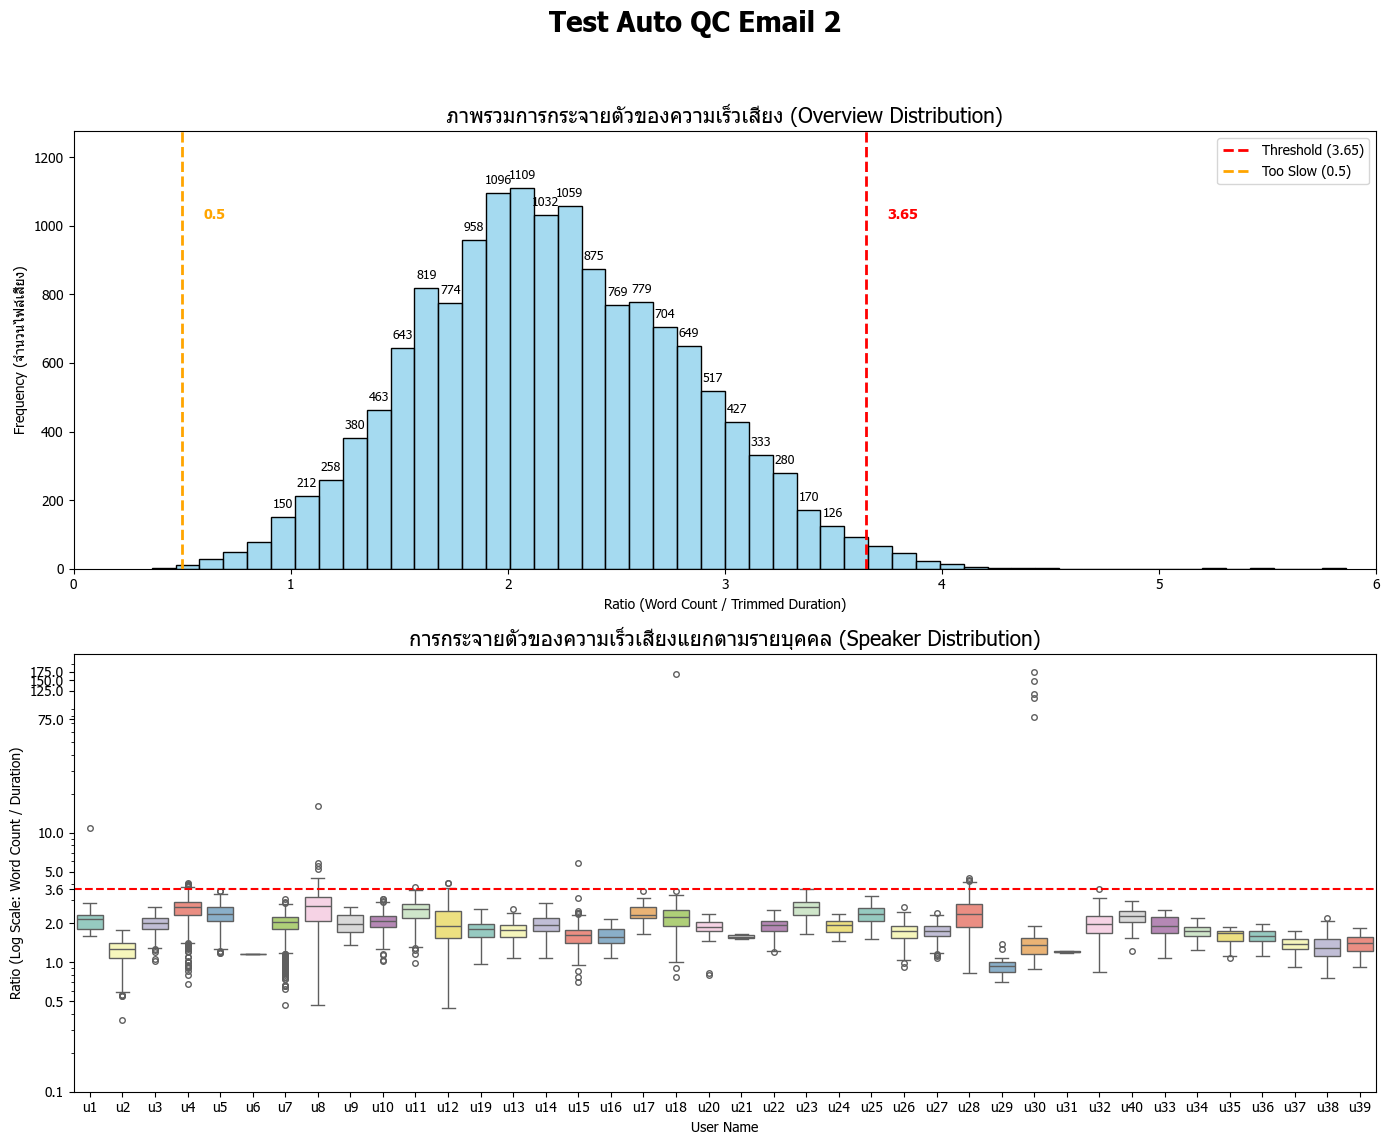

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_email2_Results_Batch.xlsx'
df_final = pd.read_excel(file_path)

# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Test Auto QC Email 2', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 3.65
threshold_slow = 0.5
ax1.axvline(3.65, color='red', linestyle='--', linewidth=2, label='Threshold (3.65)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 6)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[2] 

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, x=speaker_col, y='ratio', ax=ax2, palette='Set3', fliersize=4)

# ปรับแกน X เป็น Log Scale
ax2.set_yscale('log')
ax2.axhline(3.65, color='red', linestyle='--', linewidth=1.5)

# ปรับคำอธิบายแกน X ให้ดูง่ายขึ้นในแบบ Log
from matplotlib.ticker import ScalarFormatter
ax2.yaxis.set_major_formatter(ScalarFormatter())
ax2.set_yticks([0.1, 0.5, 1, 2, 3.65, 5, 10, 75, 125, 150, 175]) # กำหนดจุดเลขที่อยากให้โชว์

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_xlabel('User Name')
ax2.set_ylabel('Ratio (Log Scale: Word Count / Duration)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


# Percentile

In [1]:
import pandas as pd
# โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_email2_Results_Batch.xlsx'
df_final = pd.read_excel(file_path)

👤 Analysis for: u40
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 112 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 2.29
🚩 จุดตัดฝั่งเร็ว (P99.9): 2.96
🚩 จุดตัดฝั่งช้า (P0.1): 1.25


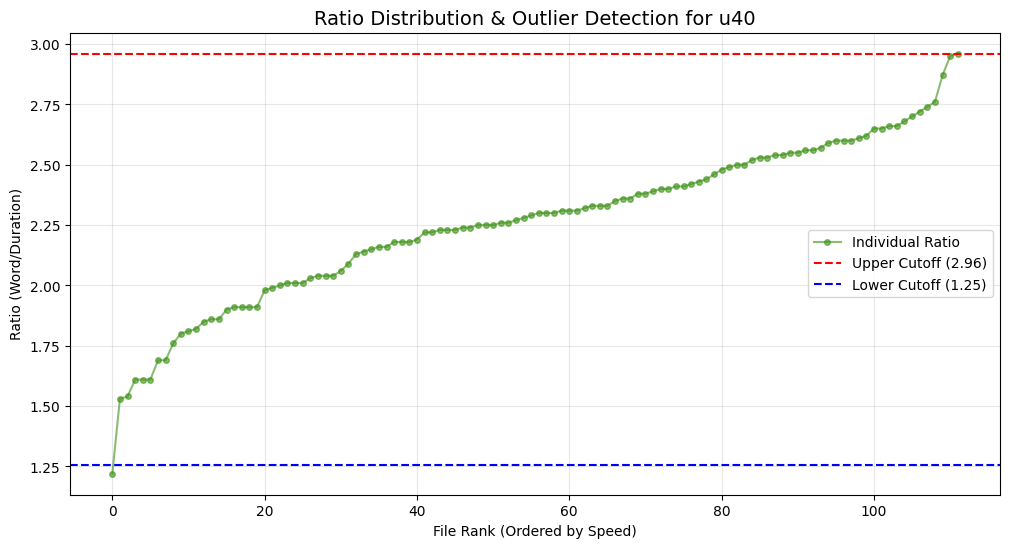

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. ดึงข้อมูลเฉพาะ User 
speaker_col = df_final.columns[2]
target_user = 'u40'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

## --- ปรับเกณฑ์ Percentile ทั้งสองฝั่ง ---
# ฝั่งเร็วผิดปกติ (Upper)
upper_p = 0.999
upper_cutoff = user_data['ratio'].quantile(upper_p)

# ฝั่งช้าผิดปกติ (Lower) - ลองดูที่ 0.5% ล่างสุด
lower_p = 0.001
lower_cutoff = user_data['ratio'].quantile(lower_p)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดตัดฝั่งเร็ว (P{upper_p*100}): {upper_cutoff:.2f}")
print(f"🚩 จุดตัดฝั่งช้า (P{lower_p*100}): {lower_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ทั้งบนและล่าง
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= "#3C9115", markersize=4, alpha=0.6, label='Individual Ratio')

# วาดเส้นจุดตัดทั้งสองฝั่ง
plt.axhline(upper_cutoff, color='red', linestyle='--', label=f'Upper Cutoff ({upper_cutoff:.2f})')
plt.axhline(lower_cutoff, color='blue', linestyle='--', label=f'Lower Cutoff ({lower_cutoff:.2f})')

plt.title(f'Ratio Distribution & Outlier Detection for {target_user}', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

#plt.yscale('symlog', linthresh=6) 

# ปรับเลขแกน Y ให้เห็นชัดทั้งช่วงต่ำและสูง
#plt.yticks([0, lower_cutoff, 2, 3,100, 125, upper_cutoff])
#plt.gca().get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.xlabel('File Rank (Ordered by Speed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Audit

In [ ]:
import IPython.display as ipd
import os
import requests
import shutil
import io
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

audit_temp_dir = 'audit_temp_samples2'

# 1. ล้างโฟลเดอร์เก่า
if os.path.exists(audit_temp_dir):
    shutil.rmtree(audit_temp_dir)
os.makedirs(audit_temp_dir)

# 2. กรองข้อมูล Outlier
samples_to_audit = user_data[
    (user_data['ratio'] >= upper_cutoff) | 
    (user_data['ratio'] <= lower_cutoff)
].copy()

print(f"👤 ตรวจสอบ User: {target_user}")
print(f"🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า {lower_cutoff:.2f} (🐢) และ สูงกว่า {upper_cutoff:.2f} (🚀)")
print(f"📦 จำนวนที่ต้อง Audit ทั้งหมด: {len(samples_to_audit)} ไฟล์")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audiourl']
    ext = os.path.splitext(audio_url)[1].split('?')[0] or '.m4a'
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}{ext}")
    
    try:
        # 3. ดาวน์โหลดไฟล์ด้วยความระมัดระวัง
        response = requests.get(audio_url, timeout=15, stream=True)
        
        if response.status_code == 200:
            content = response.content
            
            # ตรวจสอบว่าไฟล์ไม่ใช่ไฟล์เปล่า (ต้องมีขนาด > 100 bytes)
            if len(content) < 100:
                print(f"⚠️ Index {index}: ไฟล์จาก URL มีขนาดเล็กเกินไป (อาจเป็น Link เสีย)")
                continue
                
            # บันทึกไฟล์ลงเครื่อง
            with open(local_filename, 'wb') as f:
                f.write(content)
            
            # 4. ใช้ pydub ประมวลผลจากข้อมูลที่โหลดมาโดยตรง
            # ลองโหลดจากไฟล์ที่เพิ่งเขียน
            audio = AudioSegment.from_file(local_filename)
            
            print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
            print(f"📝 Text: {row['text']}")
            
            # แปลงเป็น WAV เพื่อเล่นบน Browser
            wav_io = io.BytesIO()
            audio.export(wav_io, format="wav")
            display(ipd.Audio(wav_io.getvalue()))
            
        else:
            print(f"❌ Index {index}: โหลดไม่ได้ StatusCode: {response.status_code}")

    except Exception as e:
        print(f"❌ Index {index} เกิดข้อผิดพลาด: {e}")
        
    print("-" * 30)